In [1]:
from google.colab import files
import pandas as pd
files.upload()
data = pd.read_excel("Lab Session Data (2).xlsx",
                     sheet_name="marketing_campaign")
print("First 5 rows")
print(data.head())
print("\nColumns")
for col in data.columns:
    print(col)
print("\nFeature Datatype")
for col in data.columns:
    if col == "Education":
        dtype = "Ordinal"
    elif col == "Year_Birth" or col == "Dt_Customer":
        dtype = "Interval"
    elif col == "ID" or col == "Marital_Status" or col == "AcceptedCmp1" or \
         col == "AcceptedCmp2" or col == "AcceptedCmp3" or \
         col == "AcceptedCmp4" or col == "AcceptedCmp5" or \
         col == "Complain" or col == "Response":
        dtype = "Nominal"
    else:
        dtype = "Ratio"
    print(col, "-", dtype)

Saving Lab Session Data (2).xlsx to Lab Session Data (2).xlsx
First 5 rows
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

           Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0  2012-04-09 00:00:00       58       635  ...                  7   
1  2014-08-03 00:00:00       38        11  ...                  5   
2           21-08-2013       26       426  ...                  4   
3  2014-10-02 00:00:00       26        11  ...                  6   
4           19-01-2014       94       173  ...                  5   

   AcceptedCmp3  AcceptedCmp4  AcceptedCm

In [2]:
import pandas as pd
data = pd.read_excel("Lab Session Data (2).xlsx", sheet_name="marketing_campaign")
def label_encode(column):
    unique = column.unique()
    encoded = []
    for value in column:
        number = list(unique).index(value)
        encoded.append(number)
    return encoded
def one_hot_encode(column):
    unique = column.unique()
    new_data = pd.DataFrame()
    for value in unique:
        temp = []
        for item in column:
            if item == value:
                temp.append(1)
            else:
                temp.append(0)
        new_data[value] = temp
    return new_data
education = label_encode(data["Education"])
print("Label Encoding")
print(education[:10])
marital = one_hot_encode(data["Marital_Status"])
print("\nOne Hot Encoding")
print(marital.head())

Label Encoding
[0, 0, 0, 0, 1, 2, 0, 1, 1, 1]

One Hot Encoding
   Single  Together  Married  Divorced  Widow  Alone  Absurd  YOLO
0       1         0        0         0      0      0       0     0
1       1         0        0         0      0      0       0     0
2       0         1        0         0      0      0       0     0
3       0         1        0         0      0      0       0     0
4       0         0        1         0      0      0       0     0


In [3]:
import pandas as pd
data = pd.read_excel("Lab Session Data (2).xlsx", sheet_name="marketing_campaign")
def label_encode(column):
    unique = column.unique()
    encoded = []
    for value in column:
        encoded.append(list(unique).index(value))
    return encoded
def one_hot_encode(column):
    unique = column.unique()
    new_data = pd.DataFrame()
    for value in unique:
        temp = []
        for item in column:
            if item == value:
                temp.append(1)
            else:
                temp.append(0)
        new_data[value] = temp
    return new_data
print("Original Dataset Shape")
print(data.shape)
data["Education"] = label_encode(data["Education"])
marital = one_hot_encode(data["Marital_Status"])
data = data.drop("Marital_Status", axis=1)
data = pd.concat([data, marital], axis=1)
print("\nNew Dataset Shape")
print(data.shape)
print("\nUpdated Dataset")
print(data.head())

Original Dataset Shape
(2240, 29)

New Dataset Shape
(2240, 36)

Updated Dataset
     ID  Year_Birth  Education   Income  Kidhome  Teenhome  \
0  5524        1957          0  58138.0        0         0   
1  2174        1954          0  46344.0        1         1   
2  4141        1965          0  71613.0        0         0   
3  6182        1984          0  26646.0        1         0   
4  5324        1981          1  58293.0        1         0   

           Dt_Customer  Recency  MntWines  MntFruits  ...  Z_Revenue  \
0  2012-04-09 00:00:00       58       635         88  ...         11   
1  2014-08-03 00:00:00       38        11          1  ...         11   
2           21-08-2013       26       426         49  ...         11   
3  2014-10-02 00:00:00       26        11          4  ...         11   
4           19-01-2014       94       173         43  ...         11   

   Response  Single  Together  Married  Divorced  Widow  Alone  Absurd  YOLO  
0         1       1         0     

In [4]:
import pandas as pd
data = pd.read_excel("Lab Session Data (2).xlsx", sheet_name="marketing_campaign")
def minkowski_distance(a, b, p):
    distance = 0
    for i in range(len(a)):
        distance = distance + abs(a[i] - b[i]) ** p
    distance = distance ** (1/p)
    return distance
vector1 = data.loc[0, ["Income", "MntWines", "MntFruits"]]
vector2 = data.loc[1, ["Income", "MntWines", "MntFruits"]]
manhattan = minkowski_distance(vector1, vector2, 1)
euclidean = minkowski_distance(vector1, vector2, 2)
print("Manhattan Distance")
print(manhattan)
print("\nEuclidean Distance")
print(euclidean)

Manhattan Distance
12505.0

Euclidean Distance
11810.816271536865


/tmp/ipykernel_1432/4153080019.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  distance = distance + abs(a[i] - b[i]) ** p


/tmp/ipykernel_1432/313508671.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  distance = distance + abs(a[i] - b[i]) ** p


p = 1 Distance = 12505.0
p = 2 Distance = 11810.816271536865
p = 3 Distance = 11794.583800160563
p = 4 Distance = 11794.023113078529
p = 5 Distance = 11794.000977982898
p = 6 Distance = 11794.000043117523
p = 7 Distance = 11793.999999997033
p = 8 Distance = 11794.00000000001
p = 9 Distance = 11793.999999999995
p = 10 Distance = 11794.000000000005


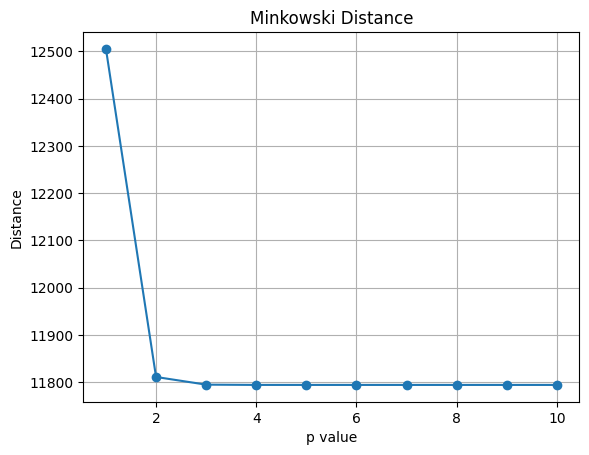

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_excel("Lab Session Data (2).xlsx", sheet_name="marketing_campaign")
def minkowski_distance(a, b, p):
    distance = 0
    for i in range(len(a)):
        distance = distance + abs(a[i] - b[i]) ** p
    distance = distance ** (1/p)
    return distance
vector1 = data.loc[0, ["Income", "MntWines", "MntFruits"]]
vector2 = data.loc[1, ["Income", "MntWines", "MntFruits"]]
p_values = []
distances = []
for p in range(1, 11):
    d = minkowski_distance(vector1, vector2, p)
    p_values.append(p)
    distances.append(d)
    print("p =", p, "Distance =", d)
plt.plot(p_values, distances, marker="o")
plt.title("Minkowski Distance")
plt.xlabel("p value")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

In [6]:
import pandas as pd
from scipy.spatial.distance import minkowski
data = pd.read_excel("Lab Session Data (2).xlsx", sheet_name="marketing_campaign")
def minkowski_distance(a, b, p):
    distance = 0
    for i in range(len(a)):
        distance = distance + abs(a[i] - b[i]) ** p
    distance = distance ** (1 / p)
    return distance
vector1 = data.loc[0, ["Income", "MntWines", "MntFruits"]]
vector2 = data.loc[1, ["Income", "MntWines", "MntFruits"]]
p = 2
my_distance = minkowski_distance(vector1, vector2, p)
scipy_distance = minkowski(vector1, vector2, p)
print("My Distance")
print(my_distance)
print("\nScipy Distance")
print(scipy_distance)

My Distance
11810.816271536865

Scipy Distance
11810.816271536865


/tmp/ipykernel_1432/2063694248.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  distance = distance + abs(a[i] - b[i]) ** p


In [7]:
import pandas as pd
import numpy as np
data = pd.read_excel("Lab Session Data (2).xlsx", sheet_name="marketing_campaign")
def dot_product(a, b):
    result = 0
    for i in range(len(a)):
        result = result + (a[i] * b[i])
    return result
def euclidean_norm(a):
    total = 0
    for i in range(len(a)):
        total = total + (a[i] ** 2)
    return total ** 0.5
vector1 = data.loc[0, ["Income", "MntWines", "MntFruits"]]
vector2 = data.loc[1, ["Income", "MntWines", "MntFruits"]]
my_dot = dot_product(vector1, vector2)
my_norm1 = euclidean_norm(vector1)
my_norm2 = euclidean_norm(vector2)
numpy_dot = np.dot(vector1, vector2)
numpy_norm1 = np.linalg.norm(vector1)
numpy_norm2 = np.linalg.norm(vector2)
print("My Dot Product")
print(my_dot)
print("\nNumpy Dot Product")
print(numpy_dot)
print("\nMy Norm of Vector 1")
print(my_norm1)
print("\nNumpy Norm of Vector 1")
print(numpy_norm1)
print("\nMy Norm of Vector 2")
print(my_norm2)
print("\nNumpy Norm of Vector 2")
print(numpy_norm2)

My Dot Product
2694354545.0

Numpy Dot Product
2694354545.0

My Norm of Vector 1
58141.53431927988

Numpy Norm of Vector 1
58141.53431927988

My Norm of Vector 2
46344.001316243724

Numpy Norm of Vector 2
46344.001316243724


/tmp/ipykernel_1432/2536431208.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  result = result + (a[i] * b[i])
/tmp/ipykernel_1432/2536431208.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = total + (a[i] ** 2)


In [8]:
import pandas as pd
data = pd.read_excel("Lab Session Data (2).xlsx", sheet_name="marketing_campaign")
data = data.select_dtypes(include="number")
def find_mean(column):
    total = 0
    for value in column:
        total = total + value
    mean = total / len(column)
    return mean
def find_variance(column):
    mean = find_mean(column)
    total = 0
    for value in column:
        total = total + (value - mean) ** 2
    variance = total / len(column)
    return variance
def find_std(column):
    variance = find_variance(column)
    std = variance ** 0.5
    return std
for col in data.columns:
    mean = find_mean(data[col])
    variance = find_variance(data[col])
    std = find_std(data[col])
    print("\nColumn :", col)
    print("Mean :", mean)
    print("Variance :", variance)
    print("Standard Deviation :", std)


Column : ID
Mean : 5592.159821428571
Variance : 10536109.703921402
Standard Deviation : 3245.9374152810465

Column : Year_Birth
Mean : 1968.8058035714287
Variance : 143.5538056042729
Standard Deviation : 11.98139414276456

Column : Income
Mean : nan
Variance : nan
Standard Deviation : nan

Column : Kidhome
Mean : 0.44419642857142855
Variance : 0.28974310427295247
Standard Deviation : 0.5382779061720372

Column : Teenhome
Mean : 0.50625
Variance : 0.296389508928571
Standard Deviation : 0.5444166684889167

Column : Recency
Mean : 49.109375
Variance : 838.4491978236607
Standard Deviation : 28.955987253479385

Column : MntWines
Mean : 303.9357142857143
Variance : 113247.2253316325
Standard Deviation : 336.5222508715174

Column : MntFruits
Mean : 26.302232142857143
Variance : 1581.219816446118
Standard Deviation : 39.76455477490121

Column : MntMeatProducts
Mean : 166.95
Variance : 50924.685000000325
Standard Deviation : 225.66498399175785

Column : MntFishProducts
Mean : 37.52544642857143

In [9]:
import pandas as pd
import numpy as np
data = pd.read_excel("Lab Session Data (2).xlsx", sheet_name="marketing_campaign")
data = data.select_dtypes(include="number")
def find_mean(column):
    total = 0
    for value in column:
        total = total + value
    return total / len(column)
def find_std(column):
    mean = find_mean(column)
    total = 0
    for value in column:
        total = total + (value - mean) ** 2
    variance = total / len(column)
    return variance ** 0.5
for col in data.columns:
    my_mean = find_mean(data[col])
    numpy_mean = np.mean(data[col])
    my_std = find_std(data[col])
    numpy_std = np.std(data[col])
    print("\nColumn:", col)
    print("My Mean:", my_mean)
    print("Numpy Mean:", numpy_mean)
    print("My Std:", my_std)
    print("Numpy Std:", numpy_std)


Column: ID
My Mean: 5592.159821428571
Numpy Mean: 5592.159821428571
My Std: 3245.9374152810465
Numpy Std: 3245.9374152810465

Column: Year_Birth
My Mean: 1968.8058035714287
Numpy Mean: 1968.8058035714287
My Std: 11.98139414276456
Numpy Std: 11.98139414276456

Column: Income
My Mean: nan
Numpy Mean: 52247.25135379061
My Std: nan
Numpy Std: 25167.39617416297

Column: Kidhome
My Mean: 0.44419642857142855
Numpy Mean: 0.44419642857142855
My Std: 0.5382779061720372
Numpy Std: 0.5382779061720372

Column: Teenhome
My Mean: 0.50625
Numpy Mean: 0.50625
My Std: 0.5444166684889167
Numpy Std: 0.5444166684889167

Column: Recency
My Mean: 49.109375
Numpy Mean: 49.109375
My Std: 28.955987253479385
Numpy Std: 28.955987253479385

Column: MntWines
My Mean: 303.9357142857143
Numpy Mean: 303.9357142857143
My Std: 336.5222508715174
Numpy Std: 336.5222508715174

Column: MntFruits
My Mean: 26.302232142857143
Numpy Mean: 26.302232142857143
My Std: 39.76455477490121
Numpy Std: 39.76455477490121

Column: MntMea

Mean: 52247.25135379061
Variance: 633397830.1872728


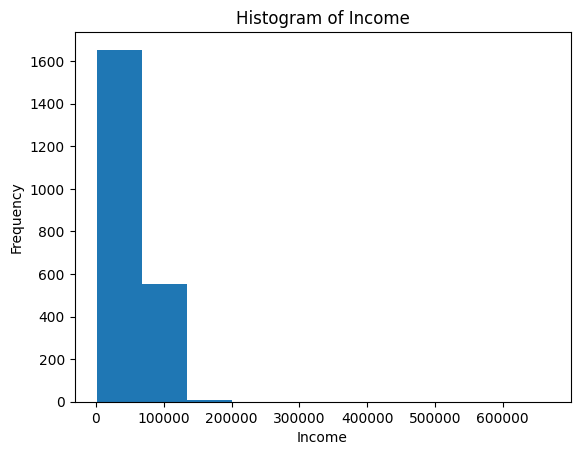

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
data = pd.read_excel("Lab Session Data (2).xlsx", sheet_name="marketing_campaign")
income = data["Income"]
mean = np.mean(income)
variance = np.var(income)
print("Mean:", mean)
print("Variance:", variance)
plt.hist(income, bins=10)
plt.title("Histogram of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()